# Industrial Sound Anomaly Detector

End-to-end anomaly detection system for industrial pump machines using a Convolutional Autoencoder trained on the MIMII Dataset.

**Architecture:** Convolutional Autoencoder (CAE) on Log-Mel Spectrograms  
**Detection Logic:** Reconstruction error (MSE) thresholding  
**Dataset:** MIMII Dataset — Pump, 6 dB SNR

## 1. Environment Setup

In [1]:
import importlib

required = {
    "torch"       : "torch",
    "torchaudio"  : "torchaudio",
    "librosa"     : "librosa",
    "streamlit"   : "streamlit",
    "matplotlib"  : "matplotlib",
    "seaborn"     : "seaborn",
    "plotly"      : "plotly",
    "sklearn"     : "scikit-learn",
    "pandas"      : "pandas",
    "numpy"       : "numpy",
    "tqdm"        : "tqdm",
}

all_ok = True
for import_name, pkg_name in required.items():
    try:
        mod = importlib.import_module(import_name)
        ver = getattr(mod, "__version__", "n/a")
        print(f"  OK  {pkg_name:<20} {ver}")
    except ImportError:
        print(f"  MISSING  {pkg_name}")
        all_ok = False

print()
print("All dependencies satisfied." if all_ok else "Install missing packages before continuing.")

  OK  torch                2.10.0+cu126
  OK  torchaudio           2.10.0+cu126
  OK  librosa              0.11.0
  OK  streamlit            1.54.0
  OK  matplotlib           3.10.8
  OK  seaborn              0.13.2
  OK  plotly               6.5.2
  OK  scikit-learn         1.7.2
  OK  pandas               2.3.3
  OK  numpy                2.2.6
  OK  tqdm                 4.67.3

All dependencies satisfied.


In [2]:
%matplotlib inline

import torch
import torchaudio
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"PyTorch version : {torch.__version__}")
print(f"Device          : {device}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
    print(f"CUDA version    : {torch.version.cuda}")

PyTorch version : 2.10.0+cu126
Device          : cuda
GPU             : NVIDIA GeForce RTX 3050 Laptop GPU
CUDA version    : 12.6


## 2. Data Acquisition

In [3]:
import zipfile
import urllib.request
import os

DATA_URL  = "https://zenodo.org/records/3384388/files/6_dB_pump.zip?download=1"
ZIP_PATH  = Path("data/6_dB_pump.zip")
DATA_ROOT = Path("data/pump")

ZIP_PATH.parent.mkdir(parents=True, exist_ok=True)

if not ZIP_PATH.exists():
    print("Downloading dataset...")
    urllib.request.urlretrieve(DATA_URL, ZIP_PATH)
    print("Download complete.")
else:
    print("ZIP file already exists, skipping download.")

if not DATA_ROOT.exists():
    print("Extracting...")
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall("data")
    print("Extraction complete.")
else:
    print("Dataset already extracted.")

ZIP file already exists, skipping download.
Dataset already extracted.


## 3. Dataset Exploration

In [4]:
all_files = list(DATA_ROOT.rglob("*.wav"))
print(f"Total WAV files: {len(all_files)}")

records = []
for f in all_files:
    parts  = f.parts
    machine_id = [p for p in parts if p.startswith("id_")]
    label  = "anomaly" if "abnormal" in parts else "normal"
    records.append({
        "path"      : str(f),
        "machine_id": machine_id[0] if machine_id else "unknown",
        "label"     : label,
    })

df = pd.DataFrame(records)
print(df.groupby(["machine_id", "label"]).size().to_string())

Total WAV files: 4205
machine_id  label  
id_00       anomaly     143
            normal     1006
id_02       anomaly     111
            normal     1005
id_04       anomaly     100
            normal      702
id_06       anomaly     102
            normal     1036


d:\personal\AI and Machine Learning\industrial anomaly sound detector\model train\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Sample rate  : 16000 Hz
Duration     : 10.00 s
Samples      : 160000


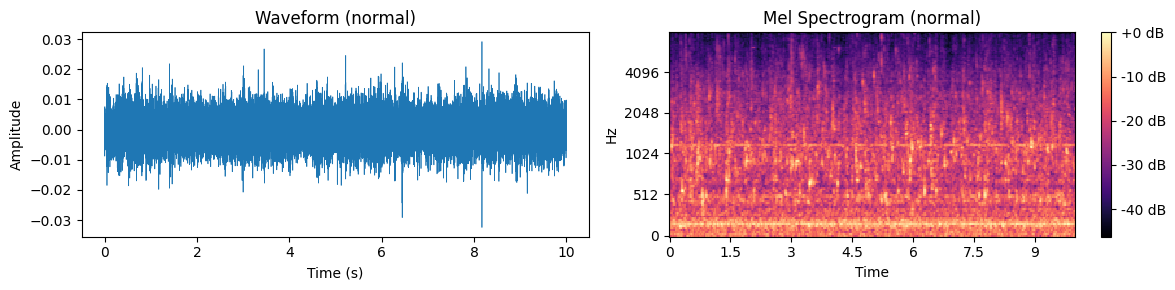

In [5]:
# Inspect one audio sample
sample_path = df[df["label"] == "normal"].iloc[0]["path"]
y, sr = librosa.load(sample_path, sr=None)

print(f"Sample rate  : {sr} Hz")
print(f"Duration     : {len(y)/sr:.2f} s")
print(f"Samples      : {len(y)}")

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].plot(np.linspace(0, len(y)/sr, len(y)), y, lw=0.5)
axes[0].set_title("Waveform (normal)")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude")

S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
S_db = librosa.power_to_db(S, ref=np.max)
img = librosa.display.specshow(S_db, sr=sr, x_axis="time", y_axis="mel", ax=axes[1])
axes[1].set_title("Mel Spectrogram (normal)")
plt.colorbar(img, ax=axes[1], format="%+2.0f dB")
plt.tight_layout()
plt.show()

## 4. Configuration

In [6]:
CFG = {
    # Audio
    "sample_rate"     : 16000,
    "segment_duration": 2.0,
    "n_mels"          : 128,
    "n_fft"           : 1024,
    "hop_length"       : 256,
    "spec_height"     : 128,
    "spec_width"      : 128,

    # Training
    "batch_size"      : 32,
    "epochs"          : 150,
    "lr"              : 1e-3,
    "latent_dim"      : 32,
    "threshold_pct"   : 90,
    "ssim_weight"     : 0.5,     # weight for SSIM loss component
    "patience"        : 15,      # early stopping patience (val AUC)

    # Paths
    "model_path"      : "model.pth",
    "machine_id"      : "id_00",
}


## 5. Preprocessing & Dataset

In [7]:
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings("ignore")


def wav_to_log_mel(path: str, cfg: dict) -> np.ndarray:
    """Load a WAV file, segment it, and return log-mel spectrograms.
    
    Returns array of shape (N_segments, 1, spec_height, spec_width).
    """
    y, sr = librosa.load(path, sr=cfg["sample_rate"])
    seg_len   = int(cfg["sample_rate"] * cfg["segment_duration"])
    segments  = [y[i:i+seg_len] for i in range(0, len(y) - seg_len + 1, seg_len)]

    specs = []
    for seg in segments:
        if len(seg) < seg_len:
            continue
        S = librosa.feature.melspectrogram(
            y=seg, sr=sr,
            n_mels=cfg["n_mels"],
            n_fft=cfg["n_fft"],
            hop_length=cfg["hop_length"],
        )
        S_db = librosa.power_to_db(S, ref=np.max)

        # Resize to fixed (spec_height, spec_width)
        if S_db.shape[1] != cfg["spec_width"]:
            S_db = np.array([
                np.interp(
                    np.linspace(0, S_db.shape[1]-1, cfg["spec_width"]),
                    np.arange(S_db.shape[1]),
                    S_db[i]
                ) for i in range(S_db.shape[0])
            ])

        # Normalize to [0, 1]
        S_norm = (S_db - S_db.min()) / (S_db.max() - S_db.min() + 1e-8)
        specs.append(S_norm[np.newaxis])  # add channel dim

    return np.stack(specs).astype(np.float32) if specs else None


class PumpDataset(Dataset):
    """PyTorch Dataset for pump sound segments."""

    def __init__(self, file_list: list, cfg: dict, label: int = 0):
        self.cfg   = cfg
        self.label = label
        self.items = []  # (path, seg_idx) pairs
        self._cache = {}  # path -> ndarray

        for path in file_list:
            specs = wav_to_log_mel(path, cfg)
            if specs is not None:
                self._cache[path] = specs
                for i in range(len(specs)):
                    self.items.append((path, i))

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        path, seg_idx = self.items[idx]
        spec = self._cache[path][seg_idx]
        return torch.from_numpy(spec), self.label

In [8]:
from sklearn.model_selection import train_test_split

machine_id = CFG["machine_id"]

all_normal  = df[(df["machine_id"] == machine_id) & (df["label"] == "normal")]["path"].tolist()
all_anomaly = df[(df["machine_id"] == machine_id) & (df["label"] == "anomaly")]["path"].tolist()

# Normal  -> 70% train / 15% val / 15% test
train_files, normal_temp = train_test_split(all_normal,  test_size=0.30, random_state=42)
val_normal_files, test_normal_files = train_test_split(normal_temp, test_size=0.50, random_state=42)

# Anomaly -> 50% val  / 50% test  (never used in training)
val_anomaly_files, test_anomaly_files = train_test_split(all_anomaly, test_size=0.50, random_state=42)

print(f"Machine ID         : {machine_id}")
print(f"Train  (normal)    : {len(train_files)} files")
print(f"Val    (normal)    : {len(val_normal_files)} files")
print(f"Val    (anomaly)   : {len(val_anomaly_files)} files")
print(f"Test   (normal)    : {len(test_normal_files)} files")
print(f"Test   (anomaly)   : {len(test_anomaly_files)} files")

print("\nBuilding datasets...")
train_ds       = PumpDataset(train_files,       CFG, label=0)
val_normal_ds  = PumpDataset(val_normal_files,  CFG, label=0)
val_anomaly_ds = PumpDataset(val_anomaly_files, CFG, label=1)
test_normal_ds  = PumpDataset(test_normal_files,  CFG, label=0)
test_anomaly_ds = PumpDataset(test_anomaly_files, CFG, label=1)

train_loader = DataLoader(train_ds, batch_size=CFG["batch_size"], shuffle=True,  num_workers=0)

val_ds  = torch.utils.data.ConcatDataset([val_normal_ds,  val_anomaly_ds])
test_ds = torch.utils.data.ConcatDataset([test_normal_ds, test_anomaly_ds])

val_loader  = DataLoader(val_ds,  batch_size=CFG["batch_size"], shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=CFG["batch_size"], shuffle=False, num_workers=0)

print(f"Train segments : {len(train_ds)}")
print(f"Val   segments : {len(val_ds)}")
print(f"Test  segments : {len(test_ds)}")

Machine ID         : id_00
Train  (normal)    : 704 files
Val    (normal)    : 151 files
Val    (anomaly)   : 71 files
Test   (normal)    : 151 files
Test   (anomaly)   : 72 files

Building datasets...
Train segments : 3520
Val   segments : 1110
Test  segments : 1115


## 6. Model Architecture — Convolutional Autoencoder

In [9]:
import torch.nn as nn


class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.LeakyReLU(0.2, inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class DeconvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=2, last=False):
        super().__init__()
        act  = nn.Sigmoid() if last else nn.LeakyReLU(0.2, inplace=True)
        norm = [] if last else [nn.BatchNorm2d(out_ch)]
        self.block = nn.Sequential(
            nn.ConvTranspose2d(in_ch, out_ch, kernel_size=3, stride=stride,
                               padding=1, output_padding=1, bias=False),
            *norm,
            act,
        )

    def forward(self, x):
        return self.block(x)


class ConvAutoencoder(nn.Module):
    """
    Convolutional Autoencoder for 128x128 single-channel mel spectrograms.

    Encoder: (1,128,128) -> (32,64,64) -> (64,32,32) -> (128,16,16) -> (128,8,8)
    Bottleneck: flatten -> Linear(latent_dim) -> Linear -> reshape
    Decoder: (128,8,8) -> (128,16,16) -> (64,32,32) -> (32,64,64) -> (1,128,128)
    """

    def __init__(self, latent_dim: int = 32):
        super().__init__()
        self.encoder_conv = nn.Sequential(
            ConvBlock(1,   32),
            ConvBlock(32,  64),
            ConvBlock(64,  128),
            ConvBlock(128, 128),
        )
        self.encoder_fc = nn.Linear(128 * 8 * 8, latent_dim)
        self.decoder_fc = nn.Linear(latent_dim, 128 * 8 * 8)
        self.decoder_conv = nn.Sequential(
            DeconvBlock(128, 128),
            DeconvBlock(128, 64),
            DeconvBlock(64,  32),
            DeconvBlock(32,  1, last=True),
        )

    def encode(self, x):
        h = self.encoder_conv(x)
        h = h.view(h.size(0), -1)
        return self.encoder_fc(h)

    def decode(self, z):
        h = self.decoder_fc(z)
        h = h.view(h.size(0), 128, 8, 8)
        return self.decoder_conv(h)

    def forward(self, x):
        return self.decode(self.encode(x))


def print_model_summary(model, input_size=(1, 1, 128, 128), device="cpu"):
    """Print a layer-by-layer summary with output shapes and parameter counts."""
    model = model.to(device)
    hooks, records = [], []

    def make_hook(name):
        def hook(module, inp, out):
            if not list(module.children()):  # leaf modules only
                n_params = sum(p.numel() for p in module.parameters())
                records.append({
                    "layer"    : name,
                    "type"     : module.__class__.__name__,
                    "out_shape": tuple(out.shape[1:]),
                    "params"   : n_params,
                })
        return hook

    for name, module in model.named_modules():
        if not list(module.children()):
            hooks.append(module.register_forward_hook(make_hook(name)))

    with torch.no_grad():
        model(torch.zeros(*input_size).to(device))

    for h in hooks:
        h.remove()

    total_params     = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    col_w = [42, 22, 20, 12]
    sep   = "-" * sum(col_w)
    header = f"{'Layer':<{col_w[0]}} {'Type':<{col_w[1]}} {'Output Shape':<{col_w[2]}} {'Params':>{col_w[3]}}"

    print(sep)
    print(header)
    print(sep)
    for r in records:
        shape_str = str(r["out_shape"])
        print(f"{r['layer']:<{col_w[0]}} {r['type']:<{col_w[1]}} {shape_str:<{col_w[2]}} {r['params']:>{col_w[3]},}")
    print(sep)
    print(f"{'Total parameters':<{col_w[0]+col_w[1]+col_w[2]}} {total_params:>{col_w[3]},}")
    print(f"{'Trainable parameters':<{col_w[0]+col_w[1]+col_w[2]}} {trainable_params:>{col_w[3]},}")
    print(f"{'Non-trainable parameters':<{col_w[0]+col_w[1]+col_w[2]}} {total_params - trainable_params:>{col_w[3]},}")
    print(sep)


model = ConvAutoencoder(latent_dim=CFG["latent_dim"]).to(device)
print_model_summary(model, device=str(device))


------------------------------------------------------------------------------------------------
Layer                                      Type                   Output Shape               Params
------------------------------------------------------------------------------------------------
encoder_conv.0.block.0                     Conv2d                 (32, 64, 64)                  288
encoder_conv.0.block.1                     BatchNorm2d            (32, 64, 64)                   64
encoder_conv.0.block.2                     LeakyReLU              (32, 64, 64)                    0
encoder_conv.1.block.0                     Conv2d                 (64, 32, 32)               18,432
encoder_conv.1.block.1                     BatchNorm2d            (64, 32, 32)                  128
encoder_conv.1.block.2                     LeakyReLU              (64, 32, 32)                    0
encoder_conv.2.block.0                     Conv2d                 (128, 16, 16)              73,728
encode

## 7. Training

In [10]:
import torch.optim as optim
from torch.cuda.amp import GradScaler, autocast
from sklearn.metrics import roc_auc_score


def ssim_loss(x, y, window_size=11):
    """Differentiable SSIM loss (1 - SSIM), computed per batch."""
    C1, C2  = 0.01**2, 0.03**2
    channel = x.size(1)
    coords  = torch.arange(window_size, dtype=x.dtype, device=x.device) - window_size // 2
    g       = torch.exp(-(coords**2) / (2 * 1.5**2))
    g      /= g.sum()
    kernel  = (g.unsqueeze(0) * g.unsqueeze(1)).unsqueeze(0).unsqueeze(0)
    kernel  = kernel.expand(channel, 1, -1, -1)
    pad     = window_size // 2
    conv    = lambda t: torch.nn.functional.conv2d(t, kernel, padding=pad, groups=channel)
    mu_x, mu_y       = conv(x), conv(y)
    sig_x  = conv(x * x) - mu_x * mu_x
    sig_y  = conv(y * y) - mu_y * mu_y
    sig_xy = conv(x * y) - mu_x * mu_y
    ssim_map = ((2 * mu_x * mu_y + C1) * (2 * sig_xy + C2)) / \
               ((mu_x**2 + mu_y**2 + C1) * (sig_x + sig_y + C2))
    return 1 - ssim_map.mean()


def combined_loss(recon, target, ssim_weight):
    mse  = torch.nn.functional.mse_loss(recon, target)
    ssim = ssim_loss(recon, target)
    return (1 - ssim_weight) * mse + ssim_weight * ssim


optimizer = optim.Adam(model.parameters(), lr=CFG["lr"], weight_decay=1e-5)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG["epochs"])
scaler    = GradScaler(enabled=torch.cuda.is_available())

train_losses = []
best_auc     = 0.0
best_epoch   = 0
patience_ctr = 0

col_w = [8, 12, 12, 12, 10, 10, 8]
header = (f"{'Epoch':>{col_w[0]}}  "
          f"{'Train Loss':>{col_w[1]}}  "
          f"{'Val Loss':>{col_w[2]}}  "
          f"{'Val AUC':>{col_w[3]}}  "
          f"{'LR':>{col_w[4]}}  "
          f"{'Best':>{col_w[5]}}")
sep = "-" * len(header)
print(sep)
print(header)
print(sep)

for epoch in range(1, CFG["epochs"] + 1):
    # Training
    model.train()
    epoch_loss = 0.0
    for specs, _ in train_loader:
        specs = specs.to(device)
        optimizer.zero_grad()
        with autocast(enabled=torch.cuda.is_available()):
            recon = model(specs)
            loss  = combined_loss(recon, specs, CFG["ssim_weight"])
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        epoch_loss += loss.item() * specs.size(0)

    avg_train_loss = epoch_loss / len(train_ds)
    train_losses.append(avg_train_loss)
    scheduler.step()

    # Validation every 5 epochs
    if epoch % 5 == 0 or epoch == 1:
        model.eval()
        val_err, val_lbl, val_loss_sum = [], [], 0.0
        with torch.no_grad():
            for specs, lbl in val_loader:
                specs = specs.to(device)
                recon = model(specs)
                mse   = ((recon - specs) ** 2).mean(dim=[1, 2, 3])
                val_loss_sum += mse.sum().item()
                val_err.extend(mse.cpu().numpy().tolist())
                val_lbl.extend(lbl.numpy().tolist())

        val_err      = np.array(val_err)
        val_lbl      = np.array(val_lbl)
        avg_val_loss = val_loss_sum / len(val_err)
        val_auc      = roc_auc_score(val_lbl, val_err)
        lr_now       = scheduler.get_last_lr()[0]
        is_best      = val_auc > best_auc

        if is_best:
            best_auc   = val_auc
            best_epoch = epoch
            torch.save(model.state_dict(), CFG["model_path"])
            patience_ctr = 0
        else:
            patience_ctr += 1

        marker = "*" if is_best else ""
        print(f"{epoch:>{col_w[0]}d}  "
              f"{avg_train_loss:>{col_w[1]}.6f}  "
              f"{avg_val_loss:>{col_w[2]}.6f}  "
              f"{val_auc:>{col_w[3]}.4f}  "
              f"{lr_now:>{col_w[4]}.2e}  "
              f"{marker:>{col_w[5]}}")

        if patience_ctr >= CFG["patience"]:
            print(sep)
            print(f"Early stopping triggered at epoch {epoch}.")
            break

print(sep)
print(f"Training complete. Best Val AUC: {best_auc:.4f} at epoch {best_epoch}.")
model.load_state_dict(torch.load(CFG["model_path"], map_location=device))
print("Best model weights loaded.")


--------------------------------------------------------------------------
   Epoch    Train Loss      Val Loss       Val AUC          LR        Best
--------------------------------------------------------------------------
       1      0.334691      0.008019        0.8889    1.00e-03           *
       5      0.273302      0.006726        0.7954    9.97e-04            
      10      0.259146      0.006952        0.8365    9.89e-04            
      15      0.253323      0.006822        0.7839    9.76e-04            
      20      0.250214      0.006775        0.7951    9.57e-04            
      25      0.247432      0.006933        0.8020    9.33e-04            
      30      0.244486      0.006923        0.7938    9.05e-04            
      35      0.241919      0.007005        0.8069    8.72e-04            
      40      0.239569      0.007192        0.8199    8.35e-04            
      45      0.237296      0.007255        0.8269    7.94e-04            
      50      0.235381   

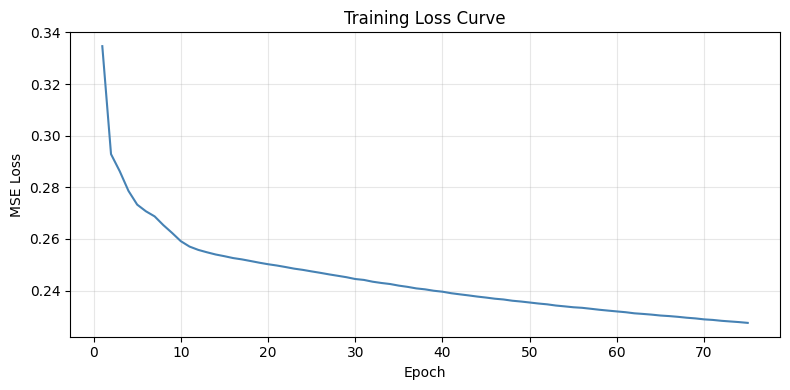

In [11]:
# Plot training loss curve
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(train_losses)+1), train_losses, color="steelblue", lw=1.5)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss Curve")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Anomaly Threshold Calibration

In [12]:
def compute_reconstruction_errors(model, loader, device):
    """Return per-sample MSE reconstruction errors and labels."""
    model.eval()
    errors = []
    labels = []

    with torch.no_grad():
        for specs, lbl in loader:
            specs = specs.to(device)
            recon = model(specs)
            mse   = ((recon - specs) ** 2).mean(dim=[1, 2, 3])
            errors.extend(mse.cpu().numpy().tolist())
            labels.extend(lbl.numpy().tolist())

    return np.array(errors), np.array(labels)


# Calibrate threshold on validation set (not test set)
val_errors, val_labels = compute_reconstruction_errors(model, val_loader, device)

# Use only normal samples from val to compute percentile
val_normal_errors = val_errors[val_labels == 0]
threshold = np.percentile(val_normal_errors, CFG["threshold_pct"])

print(f"Val normal MSE  — mean: {val_normal_errors.mean():.6f}  std: {val_normal_errors.std():.6f}")
print(f"Threshold (p{CFG['threshold_pct']})   : {threshold:.6f}")

# Quick sanity check on val set
from sklearn.metrics import roc_auc_score
val_auc = roc_auc_score(val_labels, val_errors)
print(f"Val ROC-AUC     : {val_auc:.4f}")

Val normal MSE  — mean: 0.007214  std: 0.001288
Threshold (p90)   : 0.008696
Val ROC-AUC     : 0.8889


## 9. Evaluation

In [13]:
from sklearn.metrics import (
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

test_errors, test_labels = compute_reconstruction_errors(model, test_loader, device)
predictions = (test_errors > threshold).astype(int)

auc  = roc_auc_score(test_labels, test_errors)
cm   = confusion_matrix(test_labels, predictions)
fpr, tpr, _ = roc_curve(test_labels, test_errors)

print(f"ROC-AUC Score: {auc:.4f}")
print()
print(classification_report(test_labels, predictions, target_names=["Normal", "Anomaly"]))

ROC-AUC Score: 0.9307

              precision    recall  f1-score   support

      Normal       0.91      0.90      0.90       755
     Anomaly       0.79      0.81      0.80       360

    accuracy                           0.87      1115
   macro avg       0.85      0.85      0.85      1115
weighted avg       0.87      0.87      0.87      1115



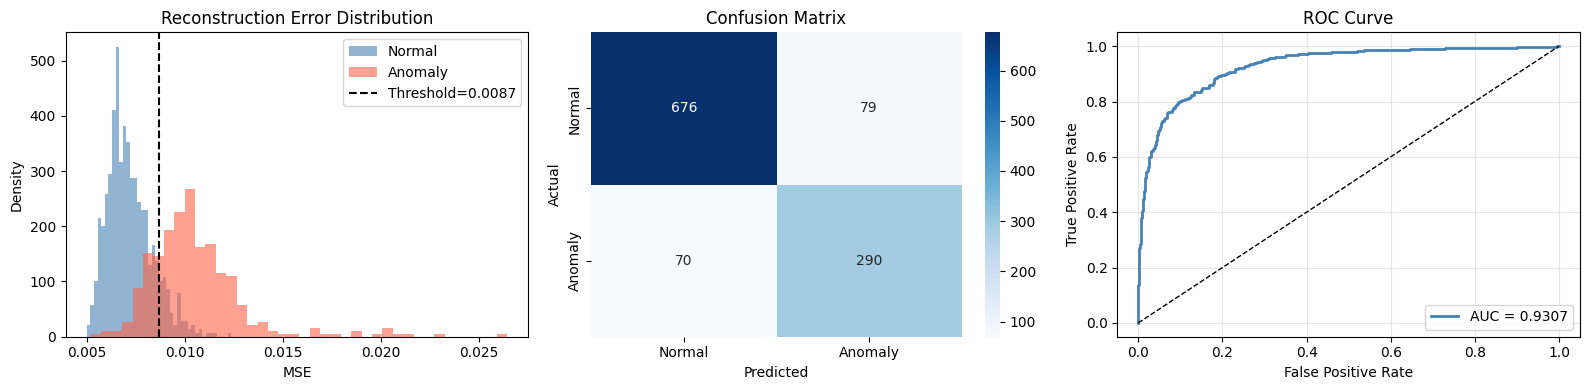

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Reconstruction error distribution
normal_err  = test_errors[test_labels == 0]
anomaly_err = test_errors[test_labels == 1]

axes[0].hist(normal_err,  bins=40, alpha=0.6, label="Normal",  color="steelblue", density=True)
axes[0].hist(anomaly_err, bins=40, alpha=0.6, label="Anomaly", color="tomato",    density=True)
axes[0].axvline(threshold, color="black", linestyle="--", lw=1.5, label=f"Threshold={threshold:.4f}")
axes[0].set_title("Reconstruction Error Distribution")
axes[0].set_xlabel("MSE")
axes[0].set_ylabel("Density")
axes[0].legend()

# Confusion matrix
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[1],
            xticklabels=["Normal", "Anomaly"],
            yticklabels=["Normal", "Anomaly"])
axes[1].set_title("Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

# ROC curve
axes[2].plot(fpr, tpr, color="steelblue", lw=2, label=f"AUC = {auc:.4f}")
axes[2].plot([0, 1], [0, 1], "k--", lw=1)
axes[2].set_title("ROC Curve")
axes[2].set_xlabel("False Positive Rate")
axes[2].set_ylabel("True Positive Rate")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Qualitative Inspection — Reconstruction Comparison

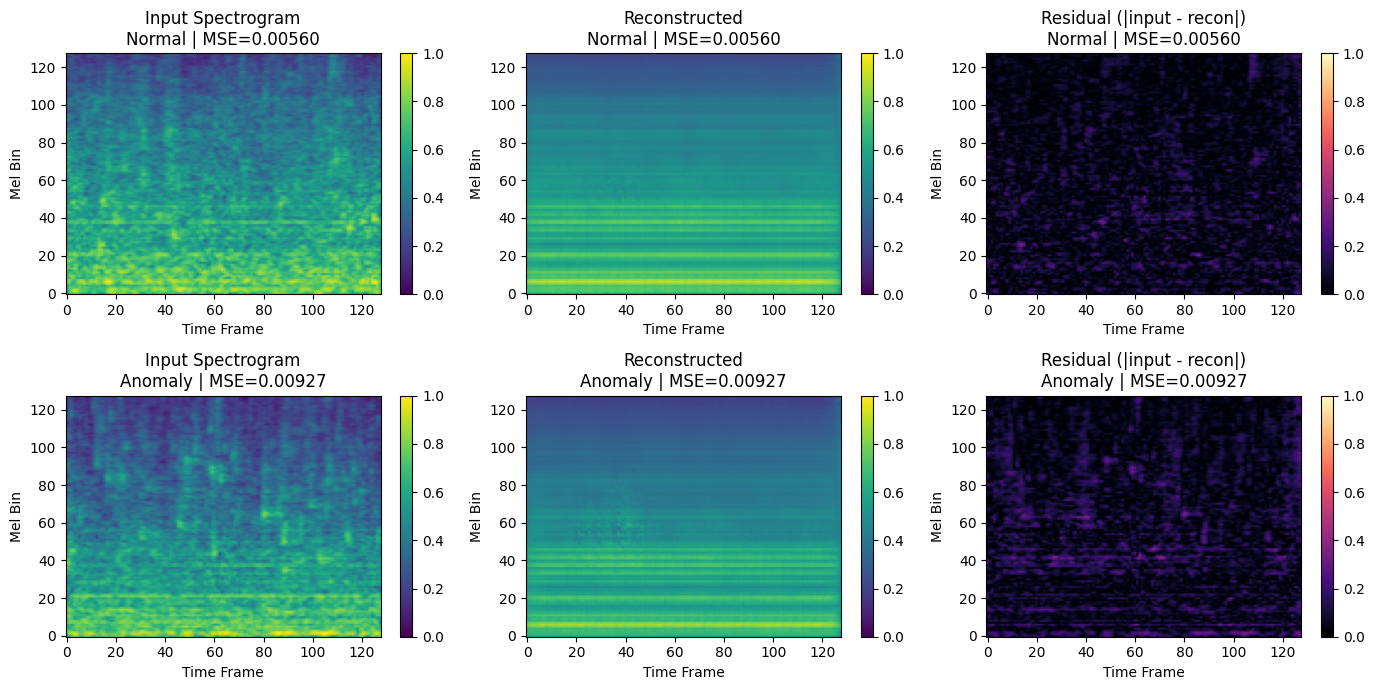

In [15]:
def get_sample_reconstruction(model, dataset, idx, device):
    model.eval()
    spec, label = dataset[idx]
    spec_t = spec.unsqueeze(0).to(device)
    with torch.no_grad():
        recon = model(spec_t)
    mse = ((recon - spec_t) ** 2).mean().item()
    return (
        spec.squeeze().numpy(),
        recon.squeeze().cpu().numpy(),
        label,
        mse,
    )


fig, axes = plt.subplots(2, 3, figsize=(14, 7))
titles = ["Input Spectrogram", "Reconstructed", "Residual (|input - recon|)"]
rows   = [(test_normal_ds, "Normal"), (test_anomaly_ds, "Anomaly")]

for row_idx, (ds, name) in enumerate(rows):
    if len(ds) == 0:
        continue
    orig, recon, lbl, mse = get_sample_reconstruction(model, ds, 0, device)
    residual = np.abs(orig - recon)

    for col_idx, (data, title) in enumerate(zip([orig, recon, residual], titles)):
        ax = axes[row_idx][col_idx]
        im = ax.imshow(data, aspect="auto", origin="lower",
                       cmap="magma" if col_idx == 2 else "viridis",
                       vmin=0, vmax=1)
        ax.set_title(f"{title}\n{name} | MSE={mse:.5f}")
        ax.set_xlabel("Time Frame")
        ax.set_ylabel("Mel Bin")
        plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

## 11. Save Model & Artifacts

In [16]:
import json

torch.save(model.state_dict(), CFG["model_path"])

artifacts = {
    "threshold"  : float(threshold),
    "auc"        : float(auc),
    "cfg"        : CFG,
    "train_losses": train_losses,
}
with open("artifacts.json", "w") as f:
    json.dump(artifacts, f, indent=2)

print(f"Model saved to    : {CFG['model_path']}")
print(f"Artifacts saved to: artifacts.json")

Model saved to    : model.pth
Artifacts saved to: artifacts.json


## 12. Streamlit Dashboard

This cell is for writing streamlit app code

In [17]:
app_py = '''\
import streamlit as st
import torch
import torch.nn as nn
import librosa
import numpy as np
import json
import tempfile
import plotly.graph_objects as go
import matplotlib.pyplot as plt


class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.LeakyReLU(0.2, inplace=True),
        )
    def forward(self, x):
        return self.block(x)


class DeconvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=2, last=False):
        super().__init__()
        act  = nn.Sigmoid() if last else nn.LeakyReLU(0.2, inplace=True)
        norm = [] if last else [nn.BatchNorm2d(out_ch)]
        self.block = nn.Sequential(
            nn.ConvTranspose2d(in_ch, out_ch, kernel_size=3, stride=stride,
                               padding=1, output_padding=1, bias=False),
            *norm, act,
        )
    def forward(self, x):
        return self.block(x)


class ConvAutoencoder(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()
        self.encoder_conv = nn.Sequential(
            ConvBlock(1, 32), ConvBlock(32, 64),
            ConvBlock(64, 128), ConvBlock(128, 128),
        )
        self.encoder_fc   = nn.Linear(128 * 8 * 8, latent_dim)
        self.decoder_fc   = nn.Linear(latent_dim, 128 * 8 * 8)
        self.decoder_conv = nn.Sequential(
            DeconvBlock(128, 128), DeconvBlock(128, 64),
            DeconvBlock(64, 32), DeconvBlock(32, 1, last=True),
        )
    def forward(self, x):
        h = self.encoder_conv(x)
        h = h.view(h.size(0), -1)
        z = self.encoder_fc(h)
        h = self.decoder_fc(z)
        h = h.view(h.size(0), 128, 8, 8)
        return self.decoder_conv(h)


@st.cache_resource
def load_model_and_artifacts():
    with open("artifacts.json") as f:
        arts = json.load(f)
    cfg   = arts["cfg"]
    model = ConvAutoencoder(latent_dim=cfg["latent_dim"])
    model.load_state_dict(torch.load(cfg["model_path"], map_location="cpu"))
    model.eval()
    return model, arts["threshold"], cfg, arts


def wav_to_log_mel(path, cfg):
    y, sr = librosa.load(path, sr=cfg["sample_rate"])
    seg_len  = int(cfg["sample_rate"] * cfg["segment_duration"])
    segments = [y[i:i+seg_len] for i in range(0, len(y) - seg_len + 1, seg_len)]
    specs = []
    for seg in segments:
        if len(seg) < seg_len:
            continue
        S    = librosa.feature.melspectrogram(y=seg, sr=sr,
                   n_mels=cfg["n_mels"], n_fft=cfg["n_fft"], hop_length=cfg["hop_length"])
        S_db = librosa.power_to_db(S, ref=np.max)
        if S_db.shape[1] != cfg["spec_width"]:
            S_db = np.array([
                np.interp(np.linspace(0, S_db.shape[1]-1, cfg["spec_width"]),
                          np.arange(S_db.shape[1]), S_db[i])
                for i in range(S_db.shape[0])
            ])
        S_norm = (S_db - S_db.min()) / (S_db.max() - S_db.min() + 1e-8)
        specs.append(S_norm[np.newaxis])
    return np.stack(specs).astype(np.float32) if specs else None


def predict(model, specs_np):
    t = torch.from_numpy(specs_np)
    with torch.no_grad():
        recon = model(t)
    mse_per_seg = ((recon - t) ** 2).mean(dim=[1, 2, 3]).numpy()
    return recon.numpy(), mse_per_seg


def gauge_chart(score, threshold):
    color = "#e74c3c" if score > threshold else "#2ecc71"
    fig   = go.Figure(go.Indicator(
        mode  = "gauge+number+delta",
        value = score,
        delta = {"reference": threshold, "valueformat": ".5f"},
        title = {"text": "Anomaly Score (MSE)"},
        number= {"valueformat": ".5f"},
        gauge = {
            "axis" : {"range": [0, threshold * 2]},
            "bar"  : {"color": color},
            "steps": [
                {"range": [0, threshold],          "color": "#d5f5e3"},
                {"range": [threshold, threshold*2], "color": "#fadbd8"},
            ],
            "threshold": {
                "line" : {"color": "black", "width": 3},
                "thickness": 0.8,
                "value": threshold,
            },
        },
    ))
    fig.update_layout(height=300, margin=dict(t=40, b=10, l=20, r=20))
    return fig


st.set_page_config(page_title="Industrial Sound Anomaly Detector", layout="wide")
st.title("Industrial Sound Anomaly Detector")
st.caption("Convolutional Autoencoder on MIMII Pump dataset - unsupervised anomaly detection")

model, threshold, cfg, arts = load_model_and_artifacts()

with st.sidebar:
    st.header("Model Info")
    st.metric("ROC-AUC", f"{arts['auc']:.4f}")
    st.metric("Threshold", f"{threshold:.6f}")
    st.metric("Latent Dim", cfg["latent_dim"])
    st.metric("Epochs Trained", cfg["epochs"])
    st.metric("Loss Function", "MSE + SSIM")
    st.metric("Machine ID", cfg["machine_id"])

uploaded = st.file_uploader("Upload a WAV file from a pump machine", type=["wav"])

if uploaded is not None:
    with tempfile.NamedTemporaryFile(suffix=".wav", delete=False) as tmp:
        tmp.write(uploaded.read())
        tmp_path = tmp.name

    st.audio(uploaded)

    specs = wav_to_log_mel(tmp_path, cfg)
    if specs is None:
        st.error("Could not extract spectrogram - file too short or invalid.")
        st.stop()

    recon_np, mse_segs = predict(model, specs)
    avg_score          = float(mse_segs.mean())
    is_anomaly         = avg_score > threshold

    if is_anomaly:
        st.error(f"ANOMALY DETECTED - Score: {avg_score:.6f} (threshold: {threshold:.6f})")
    else:
        st.success(f"NORMAL OPERATION - Score: {avg_score:.6f} (threshold: {threshold:.6f})")

    col1, col2 = st.columns([2, 1])

    with col1:
        orig     = specs[0, 0]
        rec      = recon_np[0, 0]
        residual = np.abs(orig - rec)
        fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
        for ax, data, title, cmap in zip(
            axes,
            [orig, rec, residual],
            ["Input Spectrogram", "Reconstructed", "Residual"],
            ["viridis", "viridis", "magma"],
        ):
            im = ax.imshow(data, aspect="auto", origin="lower", cmap=cmap, vmin=0, vmax=1)
            ax.set_title(title)
            ax.set_xlabel("Time Frame")
            ax.set_ylabel("Mel Bin")
            plt.colorbar(im, ax=ax)
        plt.suptitle(f"Segment 1 | MSE = {mse_segs[0]:.6f}", y=1.02)
        plt.tight_layout()
        st.pyplot(fig, use_container_width=True)

    with col2:
        st.plotly_chart(gauge_chart(avg_score, threshold), use_container_width=True)

    if len(mse_segs) > 1:
        st.subheader("Per-Segment Anomaly Scores")
        fig_seg = go.Figure()
        fig_seg.add_trace(go.Bar(
            x=list(range(1, len(mse_segs)+1)), y=mse_segs.tolist(),
            marker_color=["#e74c3c" if s > threshold else "#2ecc71" for s in mse_segs],
        ))
        fig_seg.add_hline(y=threshold, line_dash="dash", line_color="black",
                          annotation_text="Threshold")
        fig_seg.update_layout(xaxis_title="Segment", yaxis_title="MSE",
                               height=300, margin=dict(t=20, b=20))
        st.plotly_chart(fig_seg, use_container_width=True)
'''

with open("app.py", "w", encoding="utf-8") as f:
    f.write(app_py)

print("app.py written.")


app.py written.


## 13. Deployment

For deployment we will write requirements.txt in this file

In [20]:
import subprocess
result = subprocess.run(
    ["pip", "freeze"],
    capture_output=True, text=True
)

needed = {
    "torch", "torchaudio", "librosa", "streamlit",
    "matplotlib", "seaborn", "plotly", "scikit-learn",
    "pandas", "numpy", "tqdm"
}

lines = []
for line in result.stdout.splitlines():
    pkg = line.split("==")[0].lower().replace("_", "-")
    if pkg in needed:
        lines.append(line)

with open("requirements.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(lines) + "\n")

print("requirements.txt written:")
print("\n".join(lines))

requirements.txt written:
librosa==0.11.0
matplotlib==3.10.8
numpy==2.2.6
pandas==2.3.3
plotly==6.5.2
scikit-learn==1.7.2
seaborn==0.13.2
streamlit==1.54.0
torch==2.10.0+cu126
torchaudio==2.10.0+cu126
tqdm==4.67.3
